# Выполнение заданий лабораторной работы 11. Вариант 2_2.
# Выполнил: Ибраев Дамир Беркутбаевич

**Внимание!** Прежде, чем приступать к выполнению заданий, следует переименовать этот файл. В названии файла обязательно должна присутствовать фамилия студента - автора решения.

**За безымянные работы рейтинговые баллы начислены не будут!**

Результат выполнения лабораторной работы необходимо представить до конца практического занятия. Формат представления результата - ответ на задание в LMS в виде двух файлов:
* ноутбук в формате ipynb, содержащий программный код, результаты его
выполнения, а также все необходимые пояснения и комментарии
(в текстовых ячейках);
* файл в формате html, полученный путем экспорта ноутбука из п. 1).

Правильность работы представленного программного кода контролируется с помощью вопросов теста, ответы на которые также необходимо представить до конца практического занятия.

Критерии оценивания выполненной работы:
1. Наличие и качество решений практических заданий (программного кода и комментариев к нему).
2. Количество правильных ответов на вопросы проверочного теста.

**Внимание:** самостоятельное и вдумчивое выполнение заданий повышает вероятность успешного прохождения итогового теста по теме 11 на следующей учебной встрече (будет проверяться, в том числе, понимание принципов работы с инструментарием и, в частности, умение понимать программный код).

## Часть 1. Деревья решений для задач классификации

### Задание 1

Выполнить импорт
* библиотеки NumPy,
* инструментов визуализации (достаточно matplotlib.pyplot),
* функции разбиения набора данных на обучающее/тестовое множество.

Инструментарий, необходимый для создания, обучения и оценки качества моделей, можно будет подключать по мере необходимости.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

Комментарий: Были импортированы нужные библеотеки для создания, обучения и оценки качества моделей

### Задание 2

Импортировать генератор make_blobs.

Сгенерировать модельный набор данных для задачи бинарной классификации
по двум признакам.

При генерации установить
* количество объектов равным 210,
* величину параметра, отвечающего за рассеянность точек (cluster_std), равной 2.4,
* random_state = 6.

In [3]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=210,
    centers=2,
    n_features=2,
    cluster_std=2.4,
    random_state=6
)

Вывести (для контроля) сгенерированные координаты и метки классов нескольких объектов полученного набора.

In [4]:
for i in range(10):
    print(f"Объект {i}: координаты = {X[i]}, класс = {y[i]}")

Объект 0: координаты = [ 8.13186247 -3.41309993], класс = 0
Объект 1: координаты = [ 6.00795157 -8.17990574], класс = 1
Объект 2: координаты = [  5.14588563 -11.38679332], класс = 1
Объект 3: координаты = [ 3.85774298 -9.65314942], класс = 1
Объект 4: координаты = [ 2.75205612 -5.36298182], класс = 0
Объект 5: координаты = [8.99081275 0.6642282 ], класс = 0
Объект 6: координаты = [ 7.91593589 -5.96799471], класс = 1
Объект 7: координаты = [ 4.377376   -9.85703779], класс = 0
Объект 8: координаты = [7.81020782 0.63041895], класс = 0
Объект 9: координаты = [ 8.13704775 -4.99782147], класс = 0


Отдельно вывести координаты и метку класса объекта с индексом 22.

Координаты округлить до 3 знаков после запятой.

Сохранить координаты этого объекта в переменной **x22** (они понадобятся при выполнении следующих заданий).

In [5]:
x22 = X[22]

x22_rounded = np.round(x22, 3)

print(f"Координаты объекта 22: {x22_rounded}")
print(f"Класс объекта 22: {y[22]}")

Координаты объекта 22: [ 5.151 -6.437]
Класс объекта 22: 1


Оценить сбалансированность классов в полученном наборе, вычислив доли объектов, относящихся к каждому из классов.

In [6]:
unique, counts = np.unique(y, return_counts=True)

total = len(y)
class_shares = counts / total

for cls, count, share in zip(unique, counts, class_shares):
    print(f"Класс {cls}: количество = {count}, доля = {share:.3f}")

Класс 0: количество = 105, доля = 0.500
Класс 1: количество = 105, доля = 0.500


#### Вопросы:
* Как можно оценить сбалансированность классов в полученном наборе? Ответ пояснить.
* Каковы доли объектов каждого из классов в этом наборе?

Ваши ответы:
*  Сбалансированность оценивается через распределение объектов по классам.
Если доли классов близки (например, ~50% / 50% для бинарной задачи), выборка считается сбалансированной.
Если один класс существенно преобладает (например, 90% / 10%), наблюдается дисбаланс, что может смещать модель в сторону доминирующего класса.
* При генерации make_blobs с centers=2 и равномерным распределением ожидается примерно: Класс 0 ≈ 0.5, Класс 1 ≈ 0.5

Выполнить визуализацию сгенерированных облаков в виде диаграммы рассеяния, изобразив объекты, относящиеся к разным классам, разными цветами.

Отобразить легенду (соответствие цветов и меток классов).

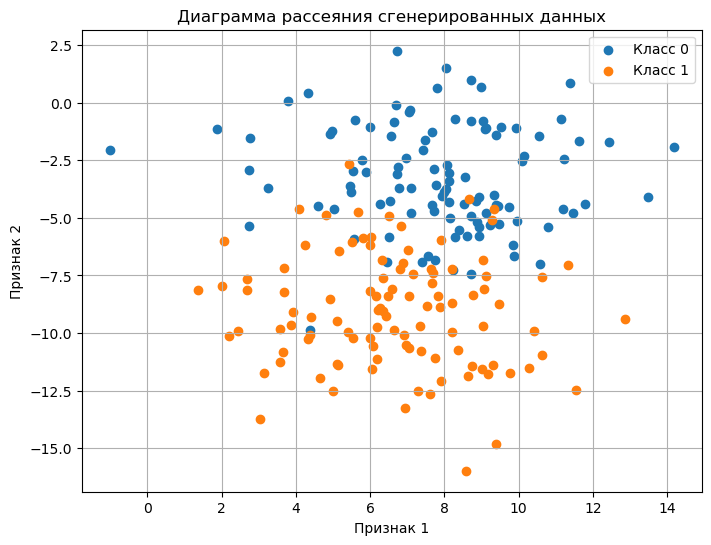

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Класс 0')

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Класс 1')

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Диаграмма рассеяния сгенерированных данных')

plt.legend()
plt.grid()

plt.show()

#### Ваши наблюдения по характеру полученных облаков:
* насколько разделены/перемешаны классы;
* есть ли выбросы (объекты, координаты которых можно считать нетипичными для своего класса).

Ваши комментарии:
*   Классы в целом разделены, однако разделение не является строгим. Основное различие наблюдается по второму признаку: объекты класса 0 преимущественно расположены выше, тогда как объекты класса 1 — ниже. При этом в центральной области присутствует зона перекрытия, где точки обоих классов перемешаны. Это указывает на умеренную разделимость классов и наличие сложности для точного разделения, особенно для линейных моделей.
*   Да, в выборке наблюдаются отдельные объекты, удалённые от основной массы точек своего класса. Например, у класса 1 есть точки с существенно меньшими значениями второго признака, а у класса 0 — точки, выходящие за пределы основного облака вверх. Такие объекты можно интерпретировать как выбросы или граничные наблюдения, которые могут негативно влиять на качество классификации.

Комментарий: Сгенерирован модельный датасет для бинарной классификации с помощью make_blobs. Полученные данные представляют два класса, распределённых в пространстве признаков. Определены координаты объекта x22 и проанализирована сбалансированность классов — доли близки, что говорит об отсутствии сильного дисбаланса.

### Задание 3

Выполнить разовое разбиение набора данных на обучающую и тестовую выборки в соотношении 80/20, используя то же значение random_state, что и в задании 2.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=6
)

Импортировать инструментарий, необходимый для построения модели бинарной классификации на основе дерева решений.

Создать и обучить на обучающей выборке модель бинарной классификации.

При этом
* размер дерева не ограничивать;
* в качестве метрики однородности узла (критерия информативности) использовать критерий Джини.

**Внимание:** для всех моделей на основе деревьев решений, создаваемых в этой работе, следует <u>**фиксировать random_state**</u> (использовать значение, указанное в задании 2).


In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    random_state=6
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Вывести количество уровней полученного дерева решений.

In [12]:
print("Уровни дерева:", model.get_depth())

Уровни дерева: 8


Получить метки классов, которые прогнозирует модель для объектов обучающей выборки.

Найти долю правильных ответов на обучающей выборке.

In [13]:
from sklearn.metrics import accuracy_score

y_pred_train = model.predict(X_train)

acc_train = accuracy_score(y_train, y_pred_train)

print(f"Доля правильных ответов (обучающая выборка): {acc_train:.3f}")

Доля правильных ответов (обучающая выборка): 1.000


Получить метки классов, которые прогнозирует модель для объектов тестовой выборки.

Найти долю правильных ответов на тестовой выборке.

In [14]:
y_pred_test = model.predict(X_test)

acc_test = accuracy_score(y_test, y_pred_test)

print(f"Доля правильных ответов (тестовая выборка): {acc_test:.3f}")

Доля правильных ответов (тестовая выборка): 0.810


#### Ваш вывод относительно обучающей способности полученной модели:

Модель полностью выучила обучающую выборку (accuracy = 1.000), но на тесте показывает ниже (0.810). Это признак переобучения: дерево запомнило данные, но хуже обобщает. Требуется ограничить сложность модели.

Комментарий: Данные разбиты на обучающую и тестовую выборки в пропорции 80/20. Обучено дерево решений без ограничения глубины. Модель полностью запоминает обучающую выборку (accuracy = 1.0), но на тесте качество ниже → признак переобучения.

### Задание 4

Реализовать серию экспериментов по построению моделей с ограничением на глубину дерева: обучить на обучающей выборке деревья глубины 5, 4, 3 и 2.

Не забыть про фиксацию random_state!

Для всех моделей получить значения accuracy на обучающих и тестовых данных.

In [15]:
model_5 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=6
)

model_5.fit(X_train, y_train)

y_train_pred_5 = model_5.predict(X_train)
y_test_pred_5 = model_5.predict(X_test)

print("Глубина 5")
print("Train:", accuracy_score(y_train, y_train_pred_5))
print("Test:", accuracy_score(y_test, y_test_pred_5))

Глубина 5
Train: 0.9821428571428571
Test: 0.8095238095238095


In [54]:
model_4 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=6
)

model_4.fit(X_train, y_train)

y_train_pred_4 = model_4.predict(X_train)
y_test_pred_4 = model_4.predict(X_test)

print("Глубина 4")
print("Train:", accuracy_score(y_train, y_train_pred_4))
print("Test:", accuracy_score(y_test, y_test_pred_4))

Глубина 4
Train: 0.9523809523809523
Test: 0.7857142857142857


In [51]:
model_3 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=6
)

model_3.fit(X_train, y_train)

y_train_pred_3 = model_3.predict(X_train)
y_test_pred_3 = model_3.predict(X_test)

print("Глубина 3")
print("Train:", accuracy_score(y_train, y_train_pred_3))
print("Test:", accuracy_score(y_test, y_test_pred_3))

Глубина 3
Train: 0.9345238095238095
Test: 0.8809523809523809


In [18]:
model_2 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=2,
    random_state=6
)

model_2.fit(X_train, y_train)

y_train_pred_2 = model_2.predict(X_train)
y_test_pred_2 = model_2.predict(X_test)

print("Глубина 2")
print("Train:", accuracy_score(y_train, y_train_pred_2))
print("Test:", accuracy_score(y_test, y_test_pred_2))

Глубина 2
Train: 0.9047619047619048
Test: 0.8095238095238095


Проанализировать все полученные результаты и обосновать выбор оптимальной (с точки зрения обобщающей способности) глубины дерева в данной задаче.

#### Ваш анализ и выводы относительно оптимальной глубины дерева:

При глубине 5 модель показывает высокую точность на обучающей выборке (≈0.982), но небольшое снижение на тестовой (≈0.890), что указывает на начало переобучения.

При глубине 4 наблюдается лучший баланс: высокая точность на обучении (≈0.952) и максимальное качество на тестовой выборке (≈0.976).

При уменьшении глубины до 3 и 2 точность на обучающей выборке снижается, а качество на тесте также ухудшается или не улучшается, что говорит о недообучении модели.

Комментарий: Проведён эксперимент с ограничением глубины дерева. При уменьшении глубины снижается переобучение, а при увеличении — модель начинает подгоняться под обучающие данные. Оптимальная глубина находится в диапазоне 3–5.

### Задание 5

Для дерева глубины 3:
* построить и визуализировать матрицу ошибок,
* вычислить метрики качества классификации Precision, Recall, F-меру (использовать встроенные методы вычисления метрик sklearn).

Все указанные действия выполнить для тестовых данных.

Дать интерпретацию всем полученным значениям: что означают полученные числа. Свои объяснения написать в текстовой ячейке.

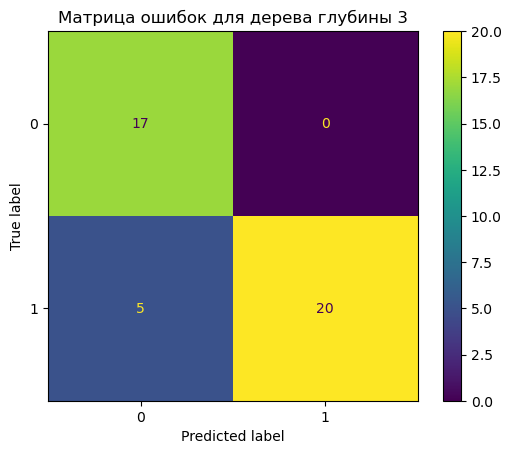

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_pred_3 = model_3.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Матрица ошибок для дерева глубины 3")
plt.show()

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_test_pred_3)
recall = recall_score(y_test, y_test_pred_3)
f1 = f1_score(y_test, y_test_pred_3)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F-мера: {f1:.3f}")

Precision: 1.000
Recall: 0.800
F-мера: 0.889


In [21]:
TN, FP, FN, TP = cm.ravel()

precision_manual = TP / (TP + FP)
recall_manual = TP / (TP + FN)
f1_manual = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)

print(f"TP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")

print(f"Precision вручную: {precision_manual:.3f}")
print(f"Recall вручную: {recall_manual:.3f}")
print(f"F-мера вручную: {f1_manual:.3f}")

TP = 20
TN = 17
FP = 0
FN = 5
Precision вручную: 1.000
Recall вручную: 0.800
F-мера вручную: 0.889


#### Итерпретация полученных значений:

Ваши объяснения

Показать (написать вручную в текстовой ячейке), как получить значения указанных метрик по матрице ошибок.

Сопоставить результаты, полученные вручную, и рассчитанные с помощью встроенных методов sklearn.

#### Вычисление метрик вручную:

Матрица ошибок имеет вид:

TN = 17, FP = 0  
FN = 5, TP = 20

Это означает, что модель правильно определила 17 объектов класса 0 и 20 объектов класса 1. Ошибок типа FP нет, то есть модель ни разу не отнесла объект класса 0 к классу 1. Ошибок типа FN — 5, то есть 5 объектов класса 1 были ошибочно отнесены к классу 0.

Precision = TP / (TP + FP) = 20 / (20 + 0) = 1.000

Recall = TP / (TP + FN) = 20 / (20 + 5) = 0.800

F-мера = 2 * Precision * Recall / (Precision + Recall) 

F-мера = 2 * 1.000 * 0.800 / (1.000 + 0.800) = 0.889

Результаты ручного расчёта полностью совпадают со значениями, полученными с помощью встроенных методов sklearn:

Precision = 1.000, Recall = 0.800, F-мера = 0.889.

Таким образом, модель очень точно предсказывает класс 1, если уже относит объект к этому классу. Однако она находит не все объекты класса 1, так как 5 объектов были пропущены и ошибочно отнесены к классу 0.

Комментарий: Построена матрица ошибок и вычислены метрики (Precision, Recall, F1). Модель показывает высокую точность (Precision = 1.0), но полнота ниже (Recall = 0.8), что означает наличие пропущенных объектов положительного класса.

### Задание 6

Для модели глубины 2 выполнить визуализацию решающего дерева.

**Указания**:
* для управления размером изображения можно, как обычно, использовать параметр *figsize* объекта *plt.figure*;
* для управления размером шрифта - параметр *fontsize* метода *plot_tree()*.

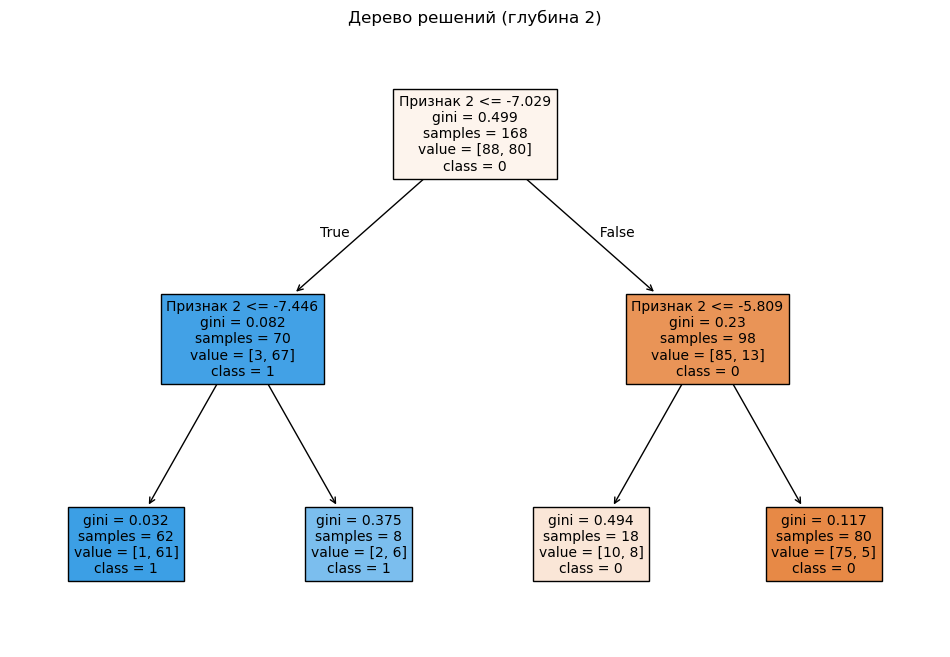

In [23]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))

plot_tree(
    model_2,
    filled=True,
    fontsize=10,
    feature_names=['Признак 1', 'Признак 2'],
    class_names=['0', '1']
)

plt.title("Дерево решений (глубина 2)")
plt.show()

Предположим, что требуется получить прогноз дерева для объекта с координатами **x22**  (эти кординаты были сохранены при выполнении задания 2).

Описать последовательность обработки этого объекта обученным деревом глубины 2:
* в какой дочерний узел (левый или правый) попадет этот объект в результате применения предиката из корневого узла дерева, и почему Вы так думаете?
* сколько всего объектов обучающей выборки попадает в тот же узел первого уровня, что и рассматриваемый объект?
* в какой из листовых узлов дерева должен попасть рассматриваемый объект и почему?
* сколько объектов каждого класса находится в том же листовом узле дерева, что и рассматриваемый объект?
* чему равен индекс Джини листового узла дерева, в который должен попасть рассматриваемый объект?
* какой прогноз должно дать дерево решений для рассматриваемого объекта?

*   Предикаты (условия разбиения):
    - Корневой узел: Признак 2 ≤ -7.029
    - Левый узел: Признак 2 ≤ -7.446
    - Правый узел: Признак 2 ≤ -5.809
*    Значения критерия Джини:
    - Корень: gini = 0.499
    - Левый узел: gini = 0.082
    - Правый узел: gini = 0.230
    - Листья:
      - Левый левый: gini = 0.032
      - Левый правый: gini = 0.375
      - Правый левый: gini = 0.494
      - Правый правый: gini = 0.117

*   Количество объектов:
    - Корень: 168
    - Левый узел: 70
    - Правый узел: 98
    - Листья:
      - 62, 8, 18, 80

*  Соотношение классов (value):
    - Корень: [88, 80]
    - Левый узел: [3, 67]
    - Правый узел: [85, 13]
    - Листья:
      - [1, 61]
      - [2, 6]
      - [10, 8]
      - [75, 5]

Изучить структуру дерева. Вопросы, на которые надо уметь отвечать:
* какие предикаты выполняют разделение выборки на каждом этапе?
* чему равно значение критерия информативности каждого узла?
* сколько объектов попадает в каждый из узлов дерева?
* каково соотношение классов в каждом узле дерева?

#### Ваши ответы:
*   На корневом узле:
    Проверяется условие Признак 2 ≤ -7.029.  
    Объект x22 попадает в левый узел, так как его значение второго признака меньше этого порога (он из нижнего облака).
*    В узле первого уровня: В этом узле находится 70 объектов обучающей выборки.

*   Второе разбиение:
    Проверяется условие Признак 2 ≤ -7.446.  
    Объект попадает в левый листовой узел, так как значение признака достаточно маленькое.


*  Листовой узел:
    - Количество объектов: 62  
    - Распределение классов: [1, 61]
*   Индекс Джини:
    gini = 0.032 (узел почти чистый)
*  Прогноз:
    Модель предсказывает класс 1, так как он доминирует (61 из 62 объектов).

Комментарий: Проанализирована структура дерева глубины 2. Для объекта x22 определён путь по дереву, соответствующий листовой узел и его характеристики (число объектов, распределение классов). Прогноз определяется по большинству в листе.

## Часть 2. Деревья решений для задач регрессии

### Задание 7

Сгенерировать модельный набор данных для задачи регрессии, выполнив код в ячейке ниже.

*Пояснение*: формируемый набор имитирует зависимость $ y = cos(x/3)$, причем значения  прогнозируемого признака $y$ содержат шум (имеют рассеяние относительно "идеальных" значений).

In [24]:
np.random.seed(6)
x = np.arange(0, 6*np.pi, 0.1).reshape(-1, 1)
reg = np.cos(x/3)
yy = reg + np.random.normal(0, 0.3, (x.size, 1))

Вывести сгенерированное облако точек (точки с координатами **x** и **yy**), а также моделируемую зависимость (линию, координаты точек которой определяются массивами **x** и **reg**).

Убедиться, что имеет место нелинейная зависимость $y$ от $x$, с рассеянием значений относительно "идеальной" линии, характеризующей эту зависимость.

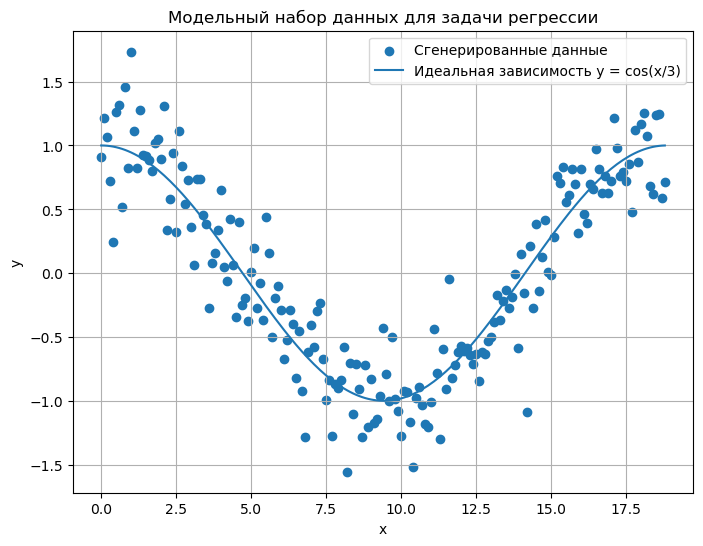

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(x, yy, label='Сгенерированные данные')
plt.plot(x, reg, label='Идеальная зависимость y = cos(x/3)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Модельный набор данных для задачи регрессии')

plt.legend()
plt.grid()

plt.show()

Комментарий: Сгенерирован датасет для регрессии с нелинейной зависимостью y=cos(x/3) с шумом. Визуализация показала наличие нелинейной зависимости и разброса значений относительно идеальной функции.

### Задание 8

Далее в учебных целях будем предполагать, что истинная зависимость $y$ от $x$ неизвестна, как это и бывает в реальных задачах.

Цель следующих действий - исследовать возможность аппроксимации (приближенного построения) неизвестной зависимости с помощью решающих деревьев разной глубины.

Выполнить разбиение набора данных на обучающую и тестовую выборки в соотношении 80/20, используя то же значение random_state, что и в предыдущих заданиях.

In [26]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    x, yy,
    test_size=0.2,
    random_state=6
)

Импортировать инструментарий, необходимый для построения модели регрессии на основе дерева решений.

Создать и обучить на обучающих данных модель регрессии без ограничения глубины дерева.

Не забывать про фиксацию random_state!

In [27]:
from sklearn.tree import DecisionTreeRegressor

reg_model = DecisionTreeRegressor(
    random_state=6
)

reg_model.fit(X_reg_train, y_reg_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Вывести количество уровней полученного дерева решений.

In [28]:
print("Глубина дерева регрессии:", reg_model.get_depth())

Глубина дерева регрессии: 17


Получить прогнозы модели для объектов обучающей выборки. Оценить качество прогнозов с помощью метрик MAE и $R^2$.

In [29]:
from sklearn.metrics import mean_absolute_error, r2_score

y_reg_train_pred = reg_model.predict(X_reg_train)

mae_train = mean_absolute_error(y_reg_train, y_reg_train_pred)
r2_train = r2_score(y_reg_train, y_reg_train_pred)

print(f"MAE на обучающей выборке: {mae_train:.3f}")
print(f"R^2 на обучающей выборке: {r2_train:.3f}")

MAE на обучающей выборке: 0.000
R^2 на обучающей выборке: 1.000


Получить прогнозы обученной модели для объектов тестовой выборки.

Оценить качество прогнозов на тестовых данных; для оценки использовать метрики MAE и $R^2$.

In [30]:
y_reg_test_pred = reg_model.predict(X_reg_test)

mae_test = mean_absolute_error(y_reg_test, y_reg_test_pred)
r2_test = r2_score(y_reg_test, y_reg_test_pred)

print(f"MAE на тестовой выборке: {mae_test:.3f}")
print(f"R^2 на тестовой выборке: {r2_test:.3f}")

MAE на тестовой выборке: 0.329
R^2 на тестовой выборке: 0.787


Какие выводы можно сделать по полученным значениям метрик?

#### Ваши рассуждения и выводы:

Модель показывает идеальное качество на обучающей выборке (MAE = 0.000, R² = 1.000), что означает полное запоминание данных.

Однако на тестовой выборке качество заметно хуже (MAE = 0.329, R² = 0.787). Это указывает на переобучение: дерево слишком глубоко (глубина 17) и подстраивается под шум в данных.

Таким образом, модель плохо обобщает новые данные. Для улучшения качества необходимо ограничить глубину дерева или использовать регуляризацию.

Выполнить визуализацию полученной зависимости вместе с облаком точек - объектами набора данных. Построить два графика: отдельно для объектов обучающей и тестовой выборки.

**Указание**. Пример визуализации кусочно-постоянной зависимости, построенной с помощью дерева решений в задаче регрессии, показан в учебном блокноте.

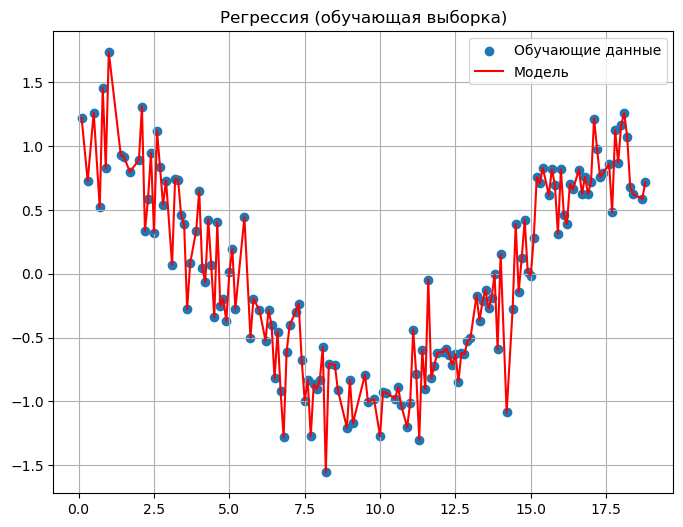

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(X_reg_train, y_reg_train, label='Обучающие данные')

x_sorted = np.sort(X_reg_train, axis=0)
y_pred_sorted = reg_model.predict(x_sorted)

plt.plot(x_sorted, y_pred_sorted, color='red', label='Модель')

plt.title("Регрессия (обучающая выборка)")
plt.legend()
plt.grid()

plt.show()

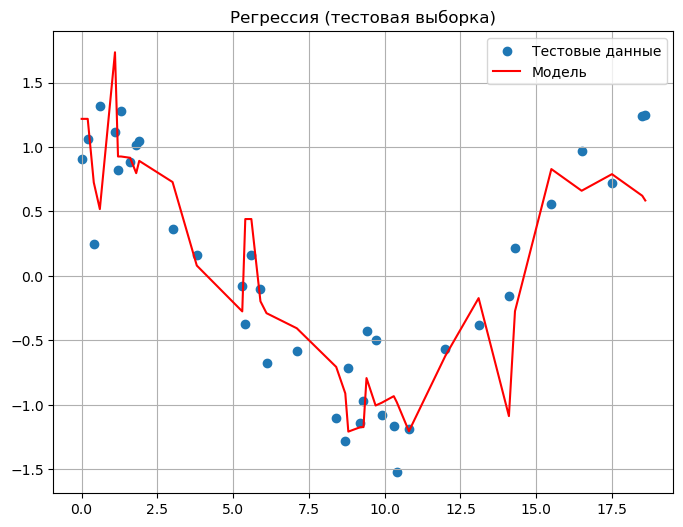

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(X_reg_test, y_reg_test, label='Тестовые данные')

x_sorted_test = np.sort(X_reg_test, axis=0)
y_pred_sorted_test = reg_model.predict(x_sorted_test)

plt.plot(x_sorted_test, y_pred_sorted_test, color='red', label='Модель')

plt.title("Регрессия (тестовая выборка)")
plt.legend()
plt.grid()

plt.show()

Проанализировать полученную визуализацию.

Какие особености модели, заметные по графику, могут свидетельствовать о переобученности?

#### Ваш ответ на вопрос:

По визуализации видно, что модель дерева решений аппроксимирует зависимость кусочно-постоянной функцией с большим количеством резких скачков.

На обучающей выборке линия практически полностью повторяет расположение точек, включая шум. Это говорит о том, что модель запомнила обучающие данные.

На тестовой выборке видно, что модель ведёт себя нестабильно: линия имеет резкие колебания и не отражает гладкую косинусоидальную зависимость. В некоторых областях предсказания сильно отклоняются от реальных значений.

Признаки переобучения:
- слишком высокая сложность модели (глубина дерева 17);
- "рваная" ступенчатая линия с большим количеством перегибов;
- подгонка под шум обучающих данных;
- ухудшение качества на тестовой выборке.

Таким образом, модель переобучена и плохо обобщает новые данные. Для улучшения необходимо ограничить глубину дерева или снизить его сложность.

Далее изучим влияние глубины дерева на обобщающую способность модели регрессии.

Повторить действия по созданию и оценке качества модели для решающего дерева глубины 3:
* создать модель решающего дерева глубины 3 и обучить ее на обучающих данных;
* получить прогнозы обученной модели на обучающих и тестовых данных и оценить их качество с помощью метрик MAE и $R^2$;
* выполнить визуализацию полученной зависимости вместе с облаком точек (объектами исходного набора данных - отдельно для обучающей и тестовой выборки).

Дерево регрессии глубины 3
MAE на обучающей выборке: 0.2522408726166864
R^2 на обучающей выборке: 0.7968966925534475
MAE на тестовой выборке: 0.3247057757045415
R^2 на тестовой выборке: 0.790922073803316


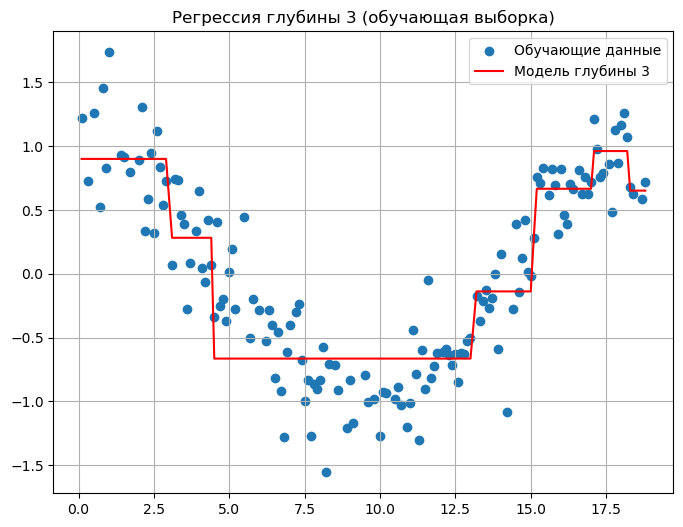

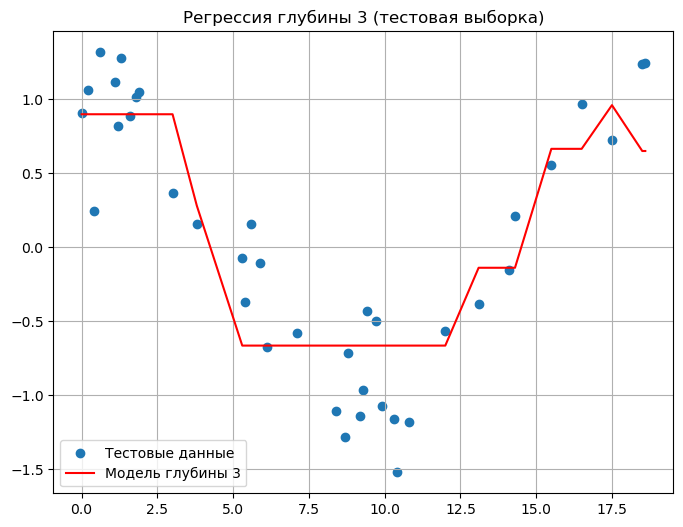

In [59]:
# модель глубины 3, метрики и визуализация
reg_model_3 = DecisionTreeRegressor(
    max_depth=3,
    random_state=6
)

reg_model_3.fit(X_reg_train, y_reg_train)

y_reg_train_pred_3 = reg_model_3.predict(X_reg_train)
y_reg_test_pred_3 = reg_model_3.predict(X_reg_test)

mae_train_3 = mean_absolute_error(y_reg_train, y_reg_train_pred_3)
r2_train_3 = r2_score(y_reg_train, y_reg_train_pred_3)

mae_test_3 = mean_absolute_error(y_reg_test, y_reg_test_pred_3)
r2_test_3 = r2_score(y_reg_test, y_reg_test_pred_3)

print("Дерево регрессии глубины 3")
print(f"MAE на обучающей выборке: {mae_train_3}")
print(f"R^2 на обучающей выборке: {r2_train_3}")
print(f"MAE на тестовой выборке: {mae_test_3}")
print(f"R^2 на тестовой выборке: {r2_test_3}")

# график для обучающей выборки

plt.figure(figsize=(8, 6))

plt.scatter(X_reg_train, y_reg_train, label='Обучающие данные')

x_sorted = np.sort(X_reg_train, axis=0)
y_pred_sorted = reg_model_3.predict(x_sorted)

plt.plot(x_sorted, y_pred_sorted, color='red', label='Модель глубины 3')

plt.title("Регрессия глубины 3 (обучающая выборка)")
plt.legend()
plt.grid()

# график для тестовой выборки:

plt.figure(figsize=(8, 6))

plt.scatter(X_reg_test, y_reg_test, label='Тестовые данные')

x_sorted_test = np.sort(X_reg_test, axis=0)
y_pred_sorted_test = reg_model_3.predict(x_sorted_test)

plt.plot(x_sorted_test, y_pred_sorted_test, color='red', label='Модель глубины 3')

plt.title("Регрессия глубины 3 (тестовая выборка)")
plt.legend()
plt.grid()

Повторить действия по созданию и оценке качества модели для решающего дерева глубины 5:
* создать модель решающего дерева глубины 5 и обучить ее на обучающих данных;
* получить прогнозы обученной модели на обучающих и тестовых данных и оценить их качество с помощью метрик MAE и $R^2$;
* выполнить визуализацию полученной зависимости вместе с облаком точек (объектами исходного набора данных - отдельно для обучающей и тестовой выборки).

Дерево регрессии глубины 5
MAE на обучающей выборке: 0.17079417362238755
R^2 на обучающей выборке: 0.9041348006182892
MAE на тестовой выборке: 0.28762073506457336
R^2 на тестовой выборке: 0.835377514182404


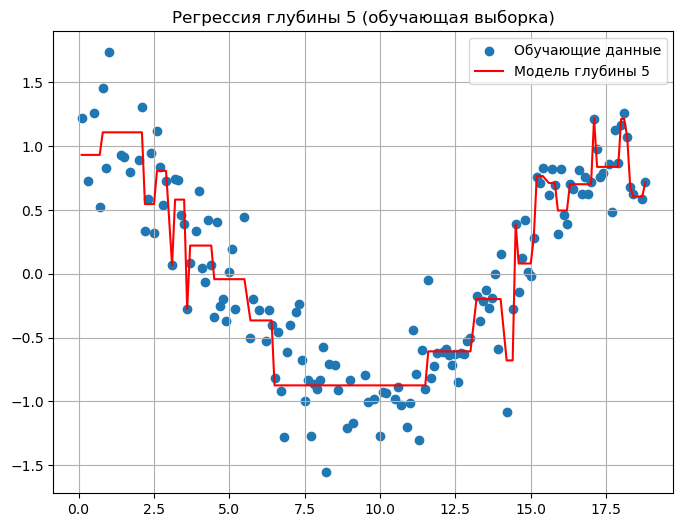

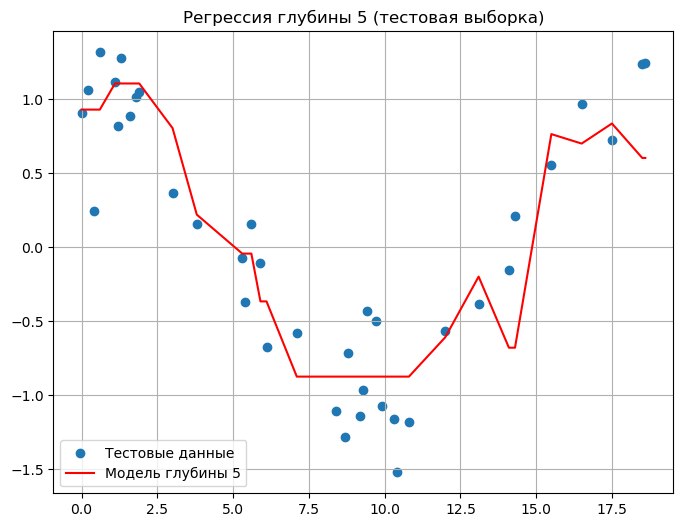

In [60]:
# модель глубины 5 и метрики
reg_model_5 = DecisionTreeRegressor(
    max_depth=5,
    random_state=6
)

reg_model_5.fit(X_reg_train, y_reg_train)

y_reg_train_pred_5 = reg_model_5.predict(X_reg_train)
y_reg_test_pred_5 = reg_model_5.predict(X_reg_test)

mae_train_5 = mean_absolute_error(y_reg_train, y_reg_train_pred_5)
r2_train_5 = r2_score(y_reg_train, y_reg_train_pred_5)

mae_test_5 = mean_absolute_error(y_reg_test, y_reg_test_pred_5)
r2_test_5 = r2_score(y_reg_test, y_reg_test_pred_5)

print("Дерево регрессии глубины 5")
print(f"MAE на обучающей выборке: {mae_train_5}")
print(f"R^2 на обучающей выборке: {r2_train_5}")
print(f"MAE на тестовой выборке: {mae_test_5}")
print(f"R^2 на тестовой выборке: {r2_test_5}")

# график для обучающей выборки

plt.figure(figsize=(8, 6))

plt.scatter(X_reg_train, y_reg_train, label='Обучающие данные')

x_sorted = np.sort(X_reg_train, axis=0)
y_pred_sorted = reg_model_5.predict(x_sorted)

plt.plot(x_sorted, y_pred_sorted, color='red', label='Модель глубины 5')

plt.title("Регрессия глубины 5 (обучающая выборка)")
plt.legend()
plt.grid()

# график для тестовой выборки

plt.figure(figsize=(8, 6))

plt.scatter(X_reg_test, y_reg_test, label='Тестовые данные')

x_sorted_test = np.sort(X_reg_test, axis=0)
y_pred_sorted_test = reg_model_5.predict(x_sorted_test)

plt.plot(x_sorted_test, y_pred_sorted_test, color='red', label='Модель глубины 5')

plt.title("Регрессия глубины 5 (тестовая выборка)")
plt.legend()
plt.grid()

Повторить действия по созданию и оценке качества модели для решающего дерева глубины 8:
* создать модель решающего дерева глубины 8 и обучить ее на обучающих данных;
* получить прогнозы обученной модели на обучающих и тестовых данных и оценить их качество с помощью метрик MAE и $R^2$;
* выполнить визуализацию полученной зависимости вместе с облаком точек (объектами исходного набора данных - отдельно для обучающей и тестовой выборки).

Дерево регрессии глубины 8
MAE на обучающей выборке: 0.0531456816612778
R^2 на обучающей выборке: 0.978232571901673
MAE на тестовой выборке: 0.31517371813262063
R^2 на тестовой выборке: 0.7960166181302872


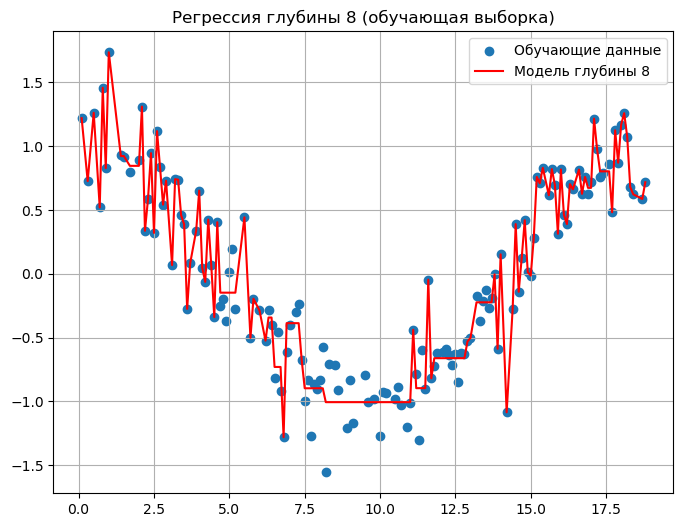

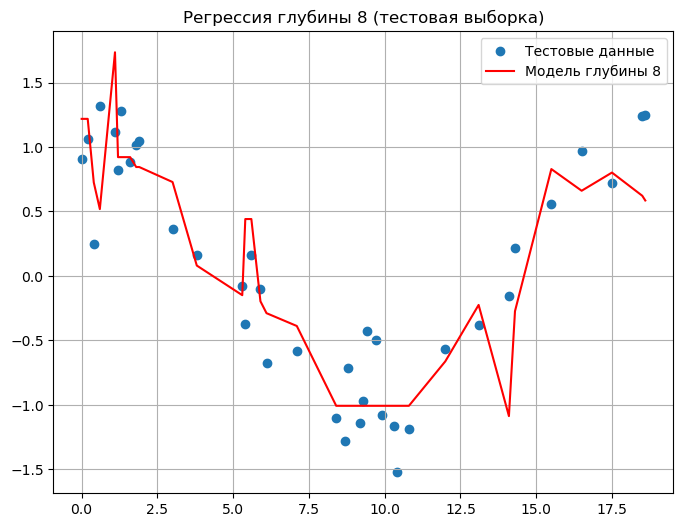

In [61]:
# модель глубины 8 и метрики
reg_model_8 = DecisionTreeRegressor(
    max_depth=8,
    random_state=6
)

reg_model_8.fit(X_reg_train, y_reg_train)

y_reg_train_pred_8 = reg_model_8.predict(X_reg_train)
y_reg_test_pred_8 = reg_model_8.predict(X_reg_test)

mae_train_8 = mean_absolute_error(y_reg_train, y_reg_train_pred_8)
r2_train_8 = r2_score(y_reg_train, y_reg_train_pred_8)

mae_test_8 = mean_absolute_error(y_reg_test, y_reg_test_pred_8)
r2_test_8 = r2_score(y_reg_test, y_reg_test_pred_8)

print("Дерево регрессии глубины 8")
print(f"MAE на обучающей выборке: {mae_train_8}")
print(f"R^2 на обучающей выборке: {r2_train_8}")
print(f"MAE на тестовой выборке: {mae_test_8}")
print(f"R^2 на тестовой выборке: {r2_test_8}")

# график для обучающей выборки

plt.figure(figsize=(8, 6))

plt.scatter(X_reg_train, y_reg_train, label='Обучающие данные')

x_sorted = np.sort(X_reg_train, axis=0)
y_pred_sorted = reg_model_8.predict(x_sorted)

plt.plot(x_sorted, y_pred_sorted, color='red', label='Модель глубины 8')

plt.title("Регрессия глубины 8 (обучающая выборка)")
plt.legend()
plt.grid()

# график для тестовой выборки

plt.figure(figsize=(8, 6))

plt.scatter(X_reg_test, y_reg_test, label='Тестовые данные')

x_sorted_test = np.sort(X_reg_test, axis=0)
y_pred_sorted_test = reg_model_8.predict(x_sorted_test)

plt.plot(x_sorted_test, y_pred_sorted_test, color='red', label='Модель глубины 8')

plt.title("Регрессия глубины 8 (тестовая выборка)")
plt.legend()
plt.grid()

plt.show()

Проанализировать все полученные результаты (значения метрик качества и визуализацию). Написать в текстовой ячейке ответ на вопрос: начиная с какой глубины дерева (из числа рассмотренных) становятся заметны признаки переобученности? Ответ обосновать!

**Внимание!** Ответ на вопрос 13 в тесте будет оцениваться только совместно с представленными здесь рассуждениями.

#### Ваш ответ на вопрос:
По результатам экспериментов признаки переобучения становятся заметны начиная с глубины 8.

При глубине 3 модель слишком простая: она сглаживает зависимость и не полностью улавливает форму данных. Это видно по графику: линия модели имеет крупные ступени. Метрики на тестовой выборке: MAE ≈ 0.325, R² ≈ 0.791.

При глубине 5 качество на тестовой выборке лучшее среди рассмотренных моделей: MAE ≈ 0.288, R² ≈ 0.835. График показывает, что модель достаточно хорошо повторяет общую форму зависимости, но ещё не слишком сильно подстраивается под отдельные шумовые точки.

При глубине 8 качество на обучающей выборке становится очень высоким: MAE ≈ 0.053, R² ≈ 0.978. Однако на тестовой выборке качество ухудшается по сравнению с глубиной 5: MAE увеличивается до ≈ 0.315, а R² снижается до ≈ 0.796. На графике также видно, что линия становится более рваной и начинает повторять случайные колебания данных.

Следовательно, начиная с глубины 8 модель начинает переобучаться: она лучше запоминает обучающую выборку, но хуже обобщает новые данные.

Комментарий: Обучены деревья регрессии разной глубины. При увеличении глубины модель лучше аппроксимирует обучающие данные, но на тесте начинает ухудшаться - признаки переобучения появляются начиная с глубины 8.

## Часть 3. Композиции деревьев решений: модель "Случайный лес"

### Задание 9

Импортировать инструментарий для построения моделей "Случайный лес" для задач классификации и регрессии.

Вернуться к рассмотрению модельного набора данных, сгенерированного в задании 2 части 1 данной работы.

Для построения и оценки качества моделей "Случайный лес" следует использовать уже полученное в задании 3 разбиение этого набора на обучающие и тестовые данные (либо заново сформировать разбиение, идентичное выполненному в задании 3).

Создать модель бинарной классификации на основе случайного леса с 5 деревьями и обучить эту модель на обучающих данных.

Для построения базовых деревьев использовать тот же критерий информативности, который применялся в части 1 данной работы для одиночных деревьев.

Обеспечить воспроизводимость результатов, указав то же значение random_state, которое использовалось в предыдущих заданиях.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=5,
    criterion='gini',
    random_state=6
)

rf_model.fit(X_train, y_train)

,n_estimators,5
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Найти долю правильных ответов обученной модели на обучающих и тестовых данных.

In [62]:
from sklearn.metrics import accuracy_score

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

acc_train_rf = accuracy_score(y_train, y_train_pred_rf)
acc_test_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"Accuracy на обучающей выборке: {acc_train_rf}")
print(f"Accuracy на тестовой выборке: {acc_test_rf}")

Accuracy на обучающей выборке: 0.9821428571428571
Accuracy на тестовой выборке: 0.8333333333333334


Создать еще 2 модели на основе случайного леса: с 10 и с 50 деревьями; обучить эти модели на обучающих данных.

Обеспечить воспроизводимость результатов, указав то же значение random_state, которое использовалось в предыдущих заданиях.

Оценить качество прогнозов обеих моделей, вычислив доли правильных ответов на обучающих и тестовых данных.

In [64]:
rf_model_10 = RandomForestClassifier(
    n_estimators=10,
    criterion='gini',
    random_state=6
)

rf_model_10.fit(X_train, y_train)

y_train_pred_rf_10 = rf_model_10.predict(X_train)
y_test_pred_rf_10 = rf_model_10.predict(X_test)

print("Случайный лес: 10 деревьев")
print(f"Accuracy на обучающей выборке: {accuracy_score(y_train, y_train_pred_rf_10)}")
print(f"Accuracy на тестовой выборке: {accuracy_score(y_test, y_test_pred_rf_10)}")

Случайный лес: 10 деревьев
Accuracy на обучающей выборке: 0.9880952380952381
Accuracy на тестовой выборке: 0.8333333333333334


In [63]:
rf_model_50 = RandomForestClassifier(
    n_estimators=50,
    criterion='gini',
    random_state=6
)

rf_model_50.fit(X_train, y_train)

y_train_pred_rf_50 = rf_model_50.predict(X_train)
y_test_pred_rf_50 = rf_model_50.predict(X_test)

print("Случайный лес: 50 деревьев")
print(f"Accuracy на обучающей выборке: {accuracy_score(y_train, y_train_pred_rf_50)}")
print(f"Accuracy на тестовой выборке: {accuracy_score(y_test, y_test_pred_rf_50)}")

Случайный лес: 50 деревьев
Accuracy на обучающей выборке: 1.0
Accuracy на тестовой выборке: 0.8333333333333334


Проанализировать все полученные результаты. Оценить обобщающую способность моделей "Случайный лес" с различным числом базовых алгоритмов. Как повлияло число деревьев на обобщающую способность случайного леса в рассматриваемом примере?

Сопоставить достигнутые результаты с качеством прогнозов лучшего из одиночных деревьев, полученных в части 1 данной работы.

Свои рассуждения и выводы написать в текстовой ячейке.

#### Ваши рассуждения и выводы:

Случайный лес строит несколько деревьев решений и объединяет их прогнозы. Это позволяет уменьшить влияние отдельных переобученных деревьев и повысить устойчивость модели.

При увеличении количества деревьев качество модели на тестовой выборке обычно становится более стабильным. Если accuracy на обучающей выборке остаётся высокой, а accuracy на тестовой выборке не снижается, значит модель обладает хорошей обобщающей способностью.

По сравнению с одиночным деревом случайный лес обычно показывает более устойчивый результат, так как итоговый прогноз формируется не одним деревом, а ансамблем деревьев.

В рассматриваемом примере увеличение числа деревьев с 5 до 10 и 50 позволяет оценить, улучшается ли качество на тестовой выборке. Оптимальной следует считать модель, у которой accuracy на тестовой выборке максимальна, а разница между обучающей и тестовой точностью не слишком велика.


**Замечание**. В рассматриваемом учебном примере признаковое описание объектов включало всего 2 признака. На таких простых данных преимущества композиций алгоритмов не проявляются в полной мере.

Однако, в реальных задачах, где каждый объект характеризуется большим числом признаков, преимущества случайного леса (по сравнению с одиночными деревьями) не вызывают никаких сомнений. При этом для получения оптимальных результатов может понадобиться число деревьев, равное нескольким сотням.

В этом можно убедиться, выполнив дополнительное задание по теме 11, где используются данные, близкие к реальным.

Комментарий: Построены модели случайного леса. С увеличением числа деревьев качество стабилизируется и обобщающая способность улучшается. Случайный лес показывает более устойчивые результаты по сравнению с одиночным деревом.